In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_csv('concertriccir2.csv' , header=None , names= ["X1" , "X2" , "Y"])

In [9]:
df.sample(5)

,X1,X2,Y
391,3.026776,2.425994,1.0
84,0.881567,-0.615122,0.0
6,0.189573,1.699962,1.0
477,1.231329,2.382158,0.0
286,3.511088,3.961144,1.0


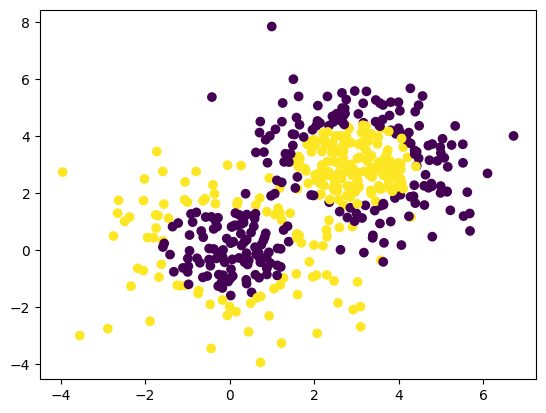

In [10]:
plt.scatter(x = df['X1'] , y = df['X2'] , c = df['Y'])

In [11]:
X = df.iloc[: , 0:2].values
y = df.iloc[:, -1].values

In [12]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

2025-12-30 15:40:31.404778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-30 15:40:31.554294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767109231.575784    1499 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767109231.585208    1499 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767109231.689545    1499 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [28]:
model = Sequential()

model.add(Dense(3 , activation='relu' , input_dim = 2))
model.add(Dense(2 , activation='relu' ))
model.add(Dense(1 , activation='sigmoid' ))

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [31]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4800 - loss: 0.6995 - val_accuracy: 0.4900 - val_loss: 0.7665
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4750 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.7619
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4600 - loss: 0.6933 - val_accuracy: 0.4900 - val_loss: 0.7576
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.4600 - loss: 0.6912 - val_accuracy: 0.4400 - val_loss: 0.7528
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4600 - loss: 0.6887 - val_accuracy: 0.4300 - val_loss: 0.7493
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4625 - loss: 0.6868 - val_accuracy: 0.4300 - val_loss: 0.7467
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4575 - loss: 0.6854 - val_accuracy: 0.4400 - val_loss: 0.7428
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4500 - loss: 0.6838 - val_accuracy: 0.4400

In [33]:
model = Sequential()

model.add(Dense(3 , activation='relu' , input_dim = 2))
model.add(BatchNormalization())
model.add(Dense(2 , activation='relu' ))
model.add(BatchNormalization())
model.add(Dense(1 , activation='sigmoid' ))

In [34]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [35]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [36]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step - accuracy: 0.4750 - loss: 0.7669 - val_accuracy: 0.5100 - val_loss: 0.7664
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4850 - loss: 0.7396 - val_accuracy: 0.5000 - val_loss: 0.7447
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4575 - loss: 0.7448 - val_accuracy: 0.5000 - val_loss: 0.7268
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4725 - loss: 0.7179 - val_accuracy: 0.5000 - val_loss: 0.7114
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4700 - loss: 0.7302 - val_accuracy: 0.5000 - val_loss: 0.6977
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4800 - loss: 0.7248 - val_accuracy: 0.5000 - val_loss: 0.6863
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4975 - loss: 0.7052 - val_accuracy: 0.5000 - val_loss: 0.6743
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5150 - loss: 0.6853 - val_accuracy: 0.5000 -

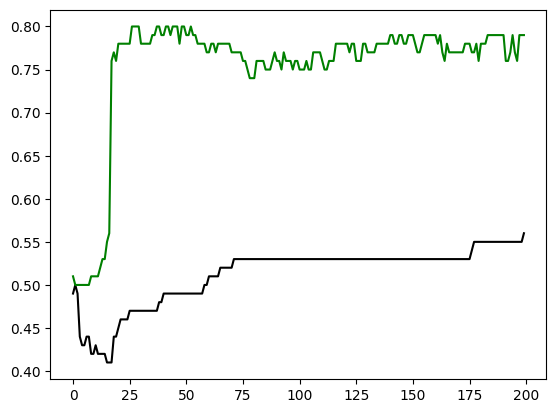

In [37]:
plt.plot(history1.history['val_accuracy'] , color = 'black')
plt.plot(history2.history['val_accuracy'] , color = 'green')

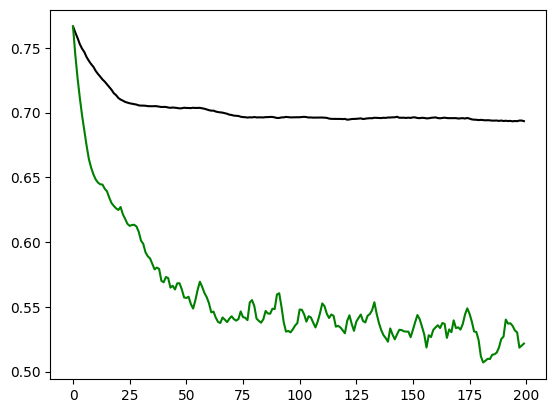

In [38]:
plt.plot(history1.history['val_loss'] , color = 'black')
plt.plot(history2.history['val_loss'] , color = 'green')